#Question 15  
This problem involves the Boston data set, which we saw in the lab for this chapter. We will now try to predict per capita crime rate using the other variables in this data set. In other words, per capita crime rate is the response, and the other variables are the predictors.

In [2]:
from ISLP import load_data
import pandas as pd

pd.set_option('display.float_format', '{:.2f}'.format)

data = load_data('Boston')

**Column Descriptions**

`crim` – Per capita crime rate by town.  
`zn` – Proportion of residential land zoned for lots over 25,000 sq.ft.  
`indus` – Proportion of non-retail business acres per town.  
`chas` – Charles River dummy variable (1 if tract bounds river; 0 otherwise).  
`nox` – Nitric oxides concentration (parts per 10 million).  
`rm` – Average number of rooms per dwelling.  
`age` – Proportion of owner-occupied units built prior to 1940.  
`dis` – Weighted distances to five Boston employment centers.  
`rad` – Index of accessibility to radial highways.  
`tax` – Full-value property-tax rate per \$10,000.  
`ptratio` – Pupil-teacher ratio by town.  
`lstat` – Percentage of lower status of the population.  
`medv` – Median value of owner-occupied homes in $1000s (target variable).  

#(a)  
For each predictor, fit a simple linear regression model to predict the response.  
Describe your results. In which of the models is there a statistically significant association between the predictor and the response?  
Create some plots to back up your assertions.

In [3]:
import pandas as pd
import statsmodels.api as sm

numeric_cols = data.select_dtypes(include=['number']).columns

y = data['medv']

results = []

for col in numeric_cols:
    if col == 'medv':
        continue
    
    X = sm.add_constant(data[[col]])
    model = sm.OLS(y, X).fit()
    
    coef = model.params[col]
    std_err = model.bse[col]
    t_value = model.tvalues[col]
    p_value = model.pvalues[col]
    conf_int = model.conf_int().loc[col]
    r2 = model.rsquared
    
    results.append({
        'Predictor': col,
        'R-squared': round(r2, 4),
        'Coef': round(coef, 4),
        'Std Err': round(std_err, 4),
        't': round(t_value, 4),
        'P>|t|': round(p_value, 4),
        'CI [0.025]': round(conf_int[0], 4),
        'CI [0.975]': round(conf_int[1], 4)
    })

summary_df = pd.DataFrame(results)

summary_df = summary_df.sort_values(by='R-squared', ascending=False)

print(summary_df)

#
slr_coe = summary_df.set_index('Predictor')['Coef'].to_dict()


   Predictor  R-squared   Coef  Std Err      t  P>|t|  CI [0.025]  CI [0.975]
11     lstat       0.54  -0.95     0.04 -24.53   0.00       -1.03       -0.87
5         rm       0.48   9.10     0.42  21.72   0.00        8.28        9.93
10   ptratio       0.26  -2.16     0.16 -13.23   0.00       -2.48       -1.84
2      indus       0.23  -0.65     0.05 -12.41   0.00       -0.75       -0.55
9        tax       0.22  -0.03     0.00 -11.91   0.00       -0.03       -0.02
4        nox       0.18 -33.92     3.20 -10.61   0.00      -40.20      -27.64
0       crim       0.15  -0.42     0.04  -9.46   0.00       -0.50       -0.33
8        rad       0.15  -0.40     0.04  -9.27   0.00       -0.49       -0.32
6        age       0.14  -0.12     0.01  -9.14   0.00       -0.15       -0.10
1         zn       0.13   0.14     0.02   8.68   0.00        0.11        0.17
7        dis       0.06   1.09     0.19   5.79   0.00        0.72        1.46
3       chas       0.03   6.35     1.59   4.00   0.00        3.2

**insights for question a**  
All the predictors listed show a statistically significant influence on the response variable, as all p-values are below 0.05.  
Among them, `lstat` and `rm` have relatively high R-squared values, around 0.5, indicating that they explain a substantial proportion of the variance in the response and therefore have stronger predictive power.

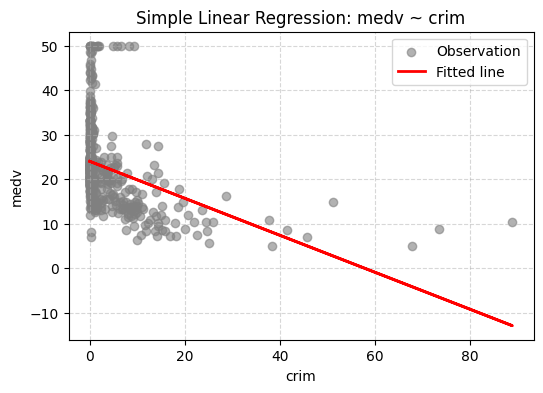

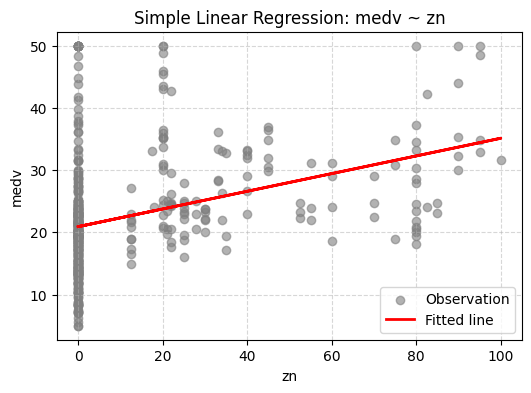

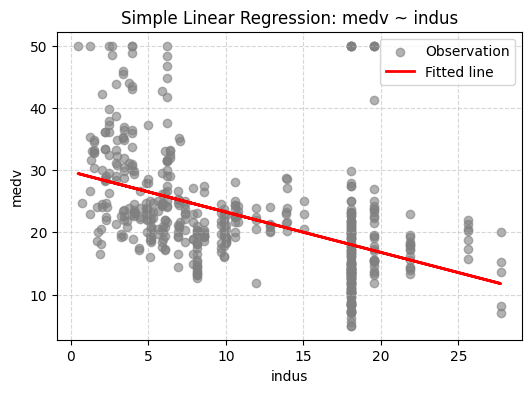

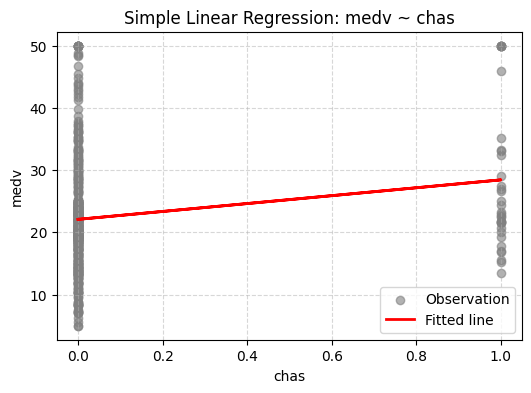

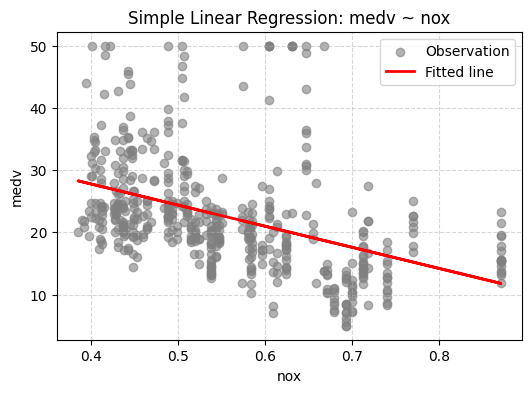

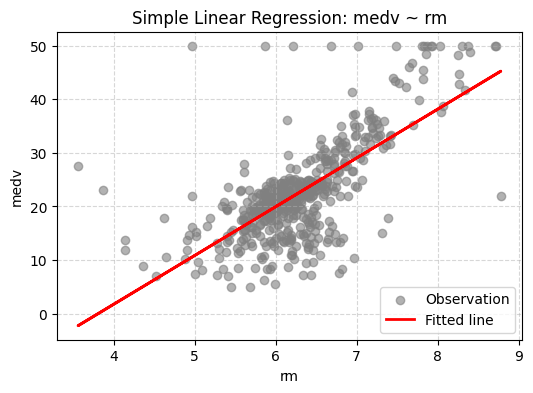

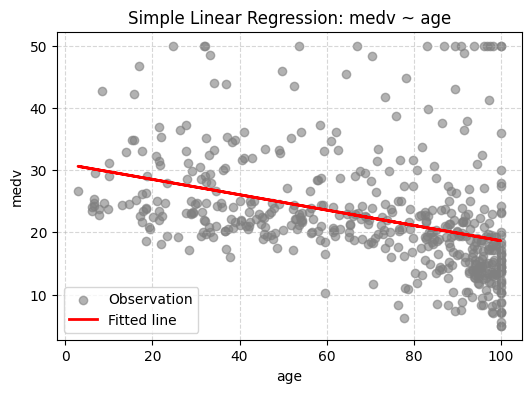

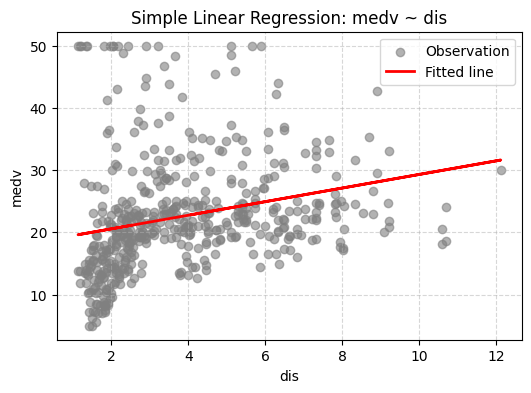

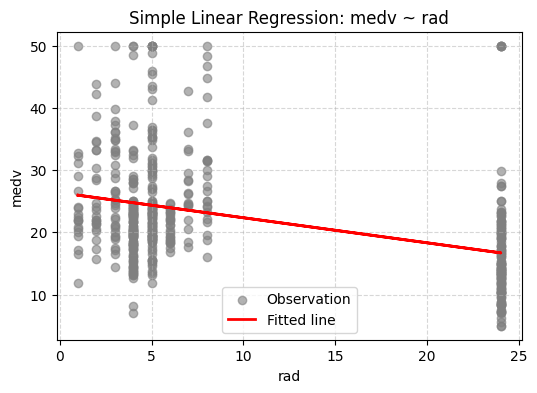

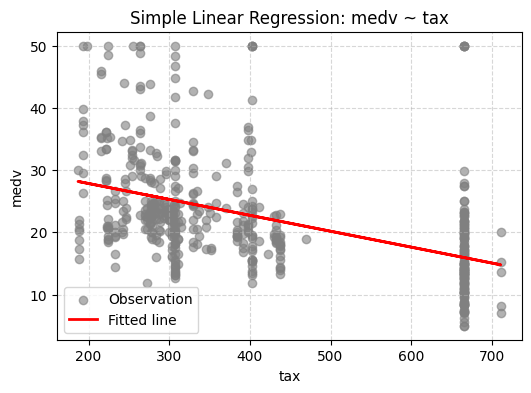

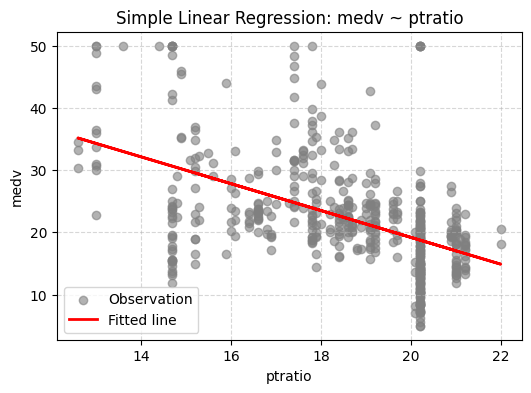

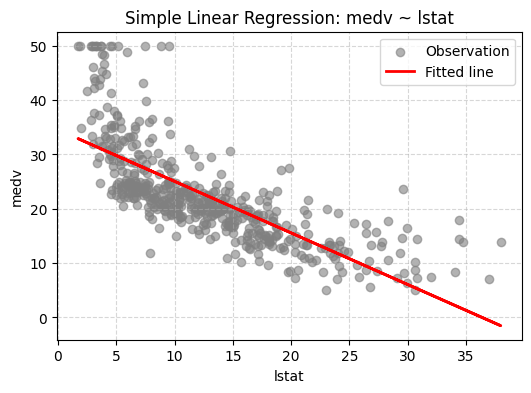

In [4]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

y = data['medv']

numeric_cols = data.select_dtypes(include=['number']).columns

for col in numeric_cols:
    if col == 'medv':
        continue
    
    X = sm.add_constant(data[[col]])
    model = sm.OLS(y, X).fit()
    
    y_pred = model.predict(X)
    
    plt.figure(figsize=(6, 4))
    plt.scatter(data[col], y, color='gray', alpha=0.6, label='Observation')
    plt.plot(data[col], y_pred, color='red', linewidth=2, label='Fitted line')
    
    plt.title(f"Simple Linear Regression: medv ~ {col}")
    plt.xlabel(col)
    plt.ylabel("medv")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()


#(b)  
Fit a multiple regression model to predict the response using all of the predictors.  
Describe your results. For which predictors can we reject the null hypothesis H0 : j =0?

In [5]:
import statsmodels.api as sm

predictors = data.select_dtypes(include=['number'])

X = predictors.drop(columns=['medv'])

X = sm.add_constant(X)
y = data['medv']

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

mlr_coe = results.params.drop('const').to_dict()

#    'coef': results.params,
#    'std_err': results.bse,
#    't_value': results.tvalues,
#    'p_value': results.pvalues

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Mon, 20 Oct 2025   Prob (F-statistic):          2.23e-133
Time:                        10:00:51   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.6173      4.936      8.431      0.0

In [6]:
summary_table = pd.DataFrame({
    'predictor': results.params.index,
    'coef': results.params.values,
    'p_value': results.pvalues.values,
    't_value': results.tvalues.values
})

significant_vars = summary_table[
    (summary_table['p_value'] < 0.05) &
    (summary_table['predictor'] != 'const')
]

significant_vars.reset_index(drop=True, inplace=True)

print(significant_vars)

  predictor   coef  p_value  t_value
0      crim  -0.12     0.00    -3.68
1        zn   0.05     0.00     3.38
2      chas   2.84     0.00     3.26
3       nox -18.76     0.00    -4.87
4        rm   3.66     0.00     8.70
5       dis  -1.49     0.00    -7.39
6       rad   0.29     0.00     4.33
7       tax  -0.01     0.00    -3.34
8   ptratio  -0.94     0.00    -7.09
9     lstat  -0.55     0.00   -10.90


**insights for question b**

The predictors `crim`, `zn`, `chas`, `nox`, `rm`, `dis`, `rad`, `tax`, `ptratio`, and `lstat` have p-values below 0.05, indicating that we can reject the null hypothesis (β = 0) for these variables. This suggests that they have a statistically significant impact on predicting `medv`.


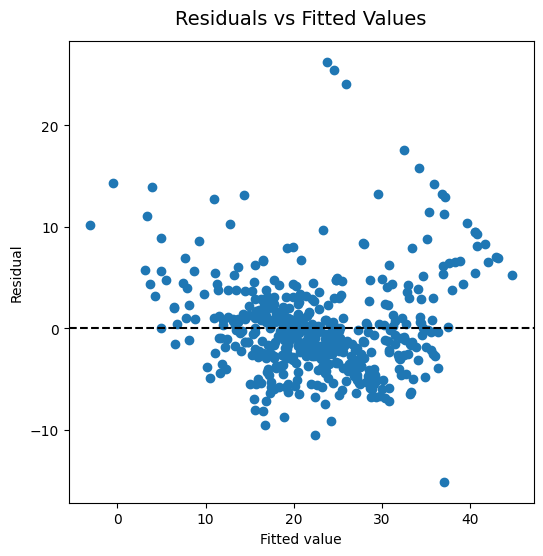

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted Values', fontsize=14, pad=12)
ax.axhline(0, c='k', ls='--')

np.int64(380)

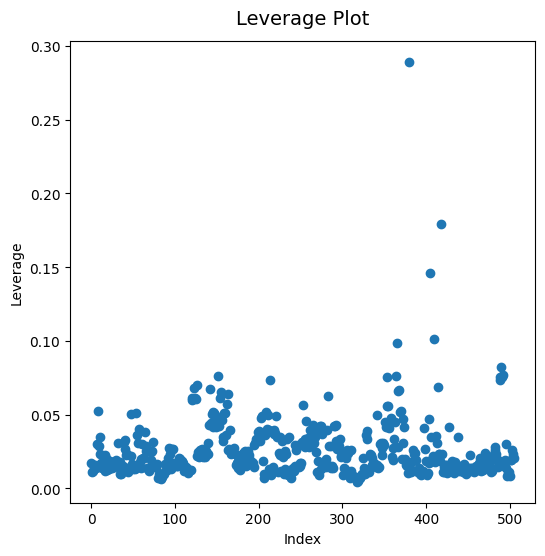

In [12]:
import matplotlib.pyplot as plt
import numpy as np
infl = results.get_influence()

ax = plt.subplots(figsize=(6,6))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
ax.set_title('Leverage Plot', fontsize=14, pad=12)
np.argmax(infl.hat_matrix_diag)

#(c)  
How do your results from (a) compare to your results from (b)? Create a plot displaying the univariate regression coefficients from (a) on the x-axis, and the multiple regression coefficients from (b) on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.


**insights for question c**  
In the multiple linear regression model, only nine predictors are statistically significant, excluding `ptratio` and `lstat`.

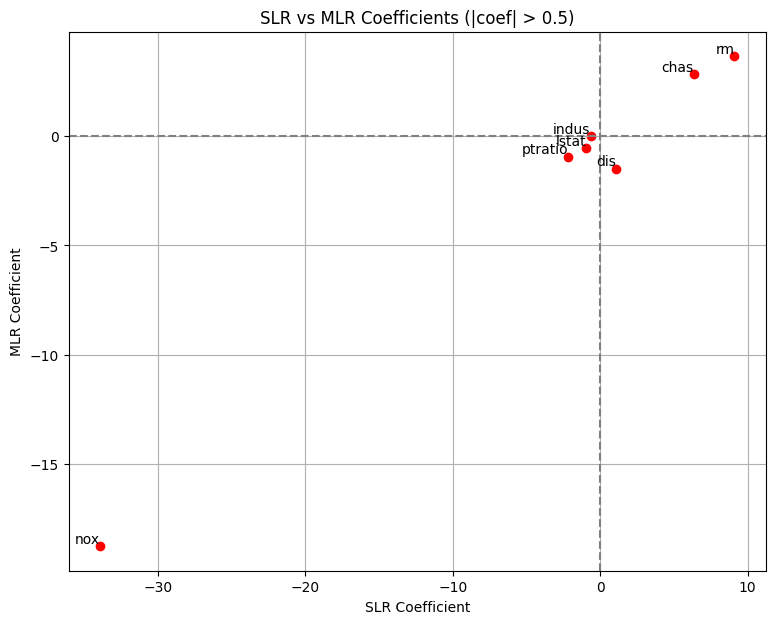

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'SLR': pd.Series(slr_coe),
    'MLR': pd.Series(mlr_coe)
})

coef_filtered = coef_df[(coef_df['SLR'].abs() > 0.5) | (coef_df['MLR'].abs() > 0.5)]

plt.figure(figsize=(9,7))
plt.scatter(coef_filtered['SLR'], coef_filtered['MLR'], color='red')

for predictor in coef_filtered.index:
    plt.text(coef_filtered.loc[predictor, 'SLR'], 
             coef_filtered.loc[predictor, 'MLR'], 
             predictor, fontsize=10, ha='right', va='bottom')

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.xlabel('SLR Coefficient')
plt.ylabel('MLR Coefficient')
plt.title('SLR vs MLR Coefficients (|coef| > 0.5)')
plt.grid(True)
plt.show()

#(d)  
Is there evidence of non-linear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form

In [40]:
import pandas as pd
import statsmodels.api as sm

numeric_cols = data.select_dtypes(include=['number']).columns
y = data['medv']

nonlinear_table = pd.DataFrame(index=[col for col in numeric_cols if col != 'medv'],
                               columns=['X^2', 'X^3'])

for col in numeric_cols:
    if col == 'medv':
        continue
    
    X = pd.DataFrame({
        col: data[col],
        f"{col}_2": data[col]**2,
        f"{col}_3": data[col]**3
    })
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()

    nonlinear_table.loc[col, 'X^2'] = 'V' if model.pvalues[f"{col}_2"] < 0.05 else '   '
    nonlinear_table.loc[col, 'X^3'] = 'V' if model.pvalues[f"{col}_3"] < 0.05 else '   '

print('Nonlinear or not:')
print(nonlinear_table)


Nonlinear or not:
         X^2  X^3
crim       V    V
zn         V    V
indus      V    V
chas             
nox             V
rm         V    V
age              
dis        V    V
rad        V    V
tax              
ptratio          
lstat      V    V
